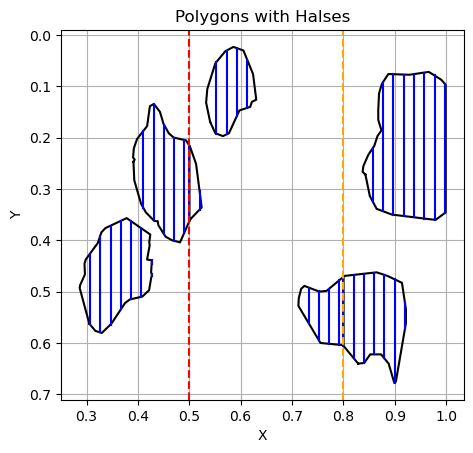

Polygon 1 is in the Left section:
  0.02, 10 (x: 0.410625, y: 0.18717777777777775)
  0.02, 10 (x: 0.410625, y: 0.33694444444444444)
  0.02, 10 (x: 0.43062500000000004, y: 0.13505555555555554)
  0.02, 10 (x: 0.43062500000000004, y: 0.3610714285714286)
  0.02, 10 (x: 0.45062500000000005, y: 0.1747222222222223)
  0.02, 10 (x: 0.45062500000000005, y: 0.3878703703703704)
  0.02, 10 (x: 0.47062500000000007, y: 0.2002508960573477)
  0.02, 10 (x: 0.47062500000000007, y: 0.401125)
  0.02, 10 (x: 0.4906250000000001, y: 0.20483870967741935)
  0.02, 10 (x: 0.4906250000000001, y: 0.38461111111111096)
Polygon 2 is in the Middle section:
  0.02, 4 (x: 0.5, y: 0.21555555555555553)
  0.02, 4 (x: 0.5, y: 0.3632777777777778)
  0.02, 4 (x: 0.52, y: 0.30343253968253997)
  0.02, 4 (x: 0.52, y: 0.340507662835249)
Polygon 3 is in the Left section:
  0.02, 16 (x: 0.30671875000000004, y: 0.42621296296296296)
  0.02, 16 (x: 0.30671875000000004, y: 0.5639814814814815)
  0.02, 16 (x: 0.32671875000000006, y: 0.3912

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString

def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]  # Удаляем первый элемент
        if not data:  # Если строка пустая, пропускаем
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))  # Пара (x, y)

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_halses(polygon, spacing):
    minx, miny, maxx, maxy = polygon.bounds
    halses = []
    x = minx
    while x <= maxx:  # Изменено на <= для включения maxx
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += spacing
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:  # Исправлено на .geoms
                halses.append(geom)
        elif intersection.geom_type == 'LineString':
            halses.append(intersection)
        x += spacing
    return halses

def split_polygon(polygon):
    lines = [LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
             LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])]
    
    split_polygons = []
    current_polygons = [polygon]

    for line in lines:
        new_polygons = []
        for poly in current_polygons:
            intersection = poly.intersection(line)
            if intersection.is_empty:
                new_polygons.append(poly)
            else:
                if poly.bounds[0] < line.coords[0][0] < poly.bounds[2]:  # Если полигон пересекает линию
                    left_poly = Polygon(list(poly.exterior.coords)[:])
                    right_poly = Polygon(list(poly.exterior.coords)[:])
                    
                    # Создаем новые полигоны на основе пересечений
                    left_poly = left_poly.intersection(Polygon([(poly.bounds[0], poly.bounds[1]), 
                                                                 (poly.bounds[0], poly.bounds[3]), 
                                                                 (line.coords[0][0], poly.bounds[3]), 
                                                                 (line.coords[0][0], poly.bounds[1])]))
                    right_poly = right_poly.intersection(Polygon([(line.coords[0][0], poly.bounds[1]), 
                                                                   (line.coords[0][0], poly.bounds[3]), 
                                                                   (poly.bounds[2], poly.bounds[3]), 
                                                                   (poly.bounds[2], poly.bounds[1])]))
                    if not left_poly.is_empty:
                        new_polygons.append(left_poly)
                    if not right_poly.is_empty:
                        new_polygons.append(right_poly)
                else:
                    new_polygons.append(poly)
        current_polygons = new_polygons

    return current_polygons

def plot_polygons_with_halses(polygons, spacing):
    fig, ax = plt.subplots()
    
    for polygon in polygons:
        x, y = polygon.exterior.xy
        ax.plot(x, y, color='black')

        # Генерация галсов для текущего полигона
        halses = create_halses(polygon, spacing)
        for line in halses:
            x, y = line.xy
            ax.plot(x, y, color='blue')

    # Добавляем линии на x = 0.5 и x = 0.8
    ax.axvline(x=0.5, color='red', linestyle='--', label='Line at x = 0.5')
    ax.axvline(x=0.8, color='orange', linestyle='--', label='Line at x = 0.8')

    ax.set_aspect('equal')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Polygons with Halses')
    plt.grid(True)  # Добавляем сетку для удобства
    plt.gca().invert_yaxis()  # Инвертируем ось Y
    plt.show()

def determine_polygon_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def print_polygon_info(polygons, spacing):
    for i, polygon in enumerate(polygons):
        halses = create_halses(polygon, spacing)
        num_points = 0
        coordinates = []  # Список для хранения координат

        for line in halses:
            x_coords = line.xy[0]
            y_coords = line.xy[1]
            num_points += len(x_coords)
            coordinates.extend(zip(x_coords, y_coords))  # Добавляем пары (x, y)

        section = determine_polygon_section(polygon)  # Определяем секцию полигона

        print(f"Polygon {i + 1} is in the {section} section:")
        for x, y in coordinates:
            print(f"  {spacing}, {num_points} (x: {x}, y: {y})")

# Укажите путь к вашему файлу
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f2_150_jpg.rf.3b9c8f231bbd0024ddf48f1b687c9e8e.txt'
polygons = parse_data(file_path)

# Разделяем полигоны
split_polygons = []
for polygon in polygons:
    split_polygons.extend(split_polygon(polygon))

# Визуализация с галсами
spacing = 0.02  # Расстояние между галсами
plot_polygons_with_halses(split_polygons, spacing)

# Вывод информации о полигонах
print_polygon_info(split_polygons, spacing)